# **Energy Consumption Forecasting for Smart Grids** 
#### Multivariate forecasting system for electricity demand with Machine Learning

---

## 1. Introduction

Accurate multivariate forecasting is critical for modern Smart Grids. Intelligent electricity networks require a delicate supply/demand balance, especially with the integration of renewable energy sources and the electrification of heating (Heat Pumps) and transport (EVs).

This project implements an end-to-end Machine Learning pipeline to predict residential electricity demand (Grid Import) using both classical statistical methods and advanced Deep Learning architectures. It culminates in a deeply interpretable model evaluation and a fully deployed, real-time MLOps monitoring dashboard.

---

## 2. Data Loading & Validation

`Household Data`, `Time series` and `Weather Data` datasets come from **Open Power System Data (OPSD)** available under the [following link](https://open-power-system-data.org/?fbclid=IwY2xjawQrXChleHRuA2FlbQIxMABicmlkETAySk9Rek9iRlhadG5obFY2c3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHrxVocPQPnX3w-NtGDF0CzSaMXon2ozmHkI4GrpsZ26X0-5tdyYfNkCLztn8_aem_VLIgUHUoLSYcNf8ToLLKHw).

#### Features of the building chosen from the `Household Data` dataset

The Residential4 building in our dataset includes measurements for the following energy-related features:

* **dishwasher** - Dishwasher energy consumption in kWh
* **ev** - Electric Vehicle charging energy in kWh
* **freezer** - Freezer energy consumption in kWh
* **grid_export** - Energy exported to the public grid in kWh
* **grid_import** - Energy imported from the public grid in kWh
* **heat_pump** - Heat pump energy consumption in kWh
* **pv** - Total Photovoltaic energy generation in kWh
* **refrigerator** - Refrigerator energy consumption in kWh
* **washing_machine** - Washing machine energy consumption in kWh

Hereafter, all features excluding `grid_export, grid_import, pv` are collectively referred to as **appliances**.

The dataset consists of measurements collected from a German trial site in Konstanz.

#### Weather Features from the `Weather Data` dataset

The dataset includes the following weather variables for Germany:

* **temperature** - Temperature in degrees Celsius (°C)
* **radiation_direct_horizontal** - Direct solar radiation hitting a horizontal surface in watts per square meter (W/m²)
* **radiation_diffuse_horizontal** - Diffuse solar radiation hitting a horizontal surface in watts per square meter (W/m²)

Note that we did not use features from the `Time series` dataset. However, the relevant analysis is presented in `notebooks/01_eda.ipynb`.

---

## 3. Exploratory Data Analysis (EDA)

This section provides a high-level summary of the Exploratory Data Analysis (EDA). For the full, detailed analysis, please refer to the corresponding notebook at `notebooks/01_eda.ipynb`.

The selected data span covers the period from October 2015 to March 2017, as this time frame contained the fewest missing values.

To determine our target variable, we analyzed the cumulative and differentiated time series presented below. After comparing the net balance (`grid_import` + `pv` - `grid_export` - `appliances`) against just `grid_import`, we found that the latter is the correct choice and have adopted it for this project. This decision was driven by the fact that the net balance calculation yielded negative values at times, which does not align with the expected physical behavior of our target metrics.

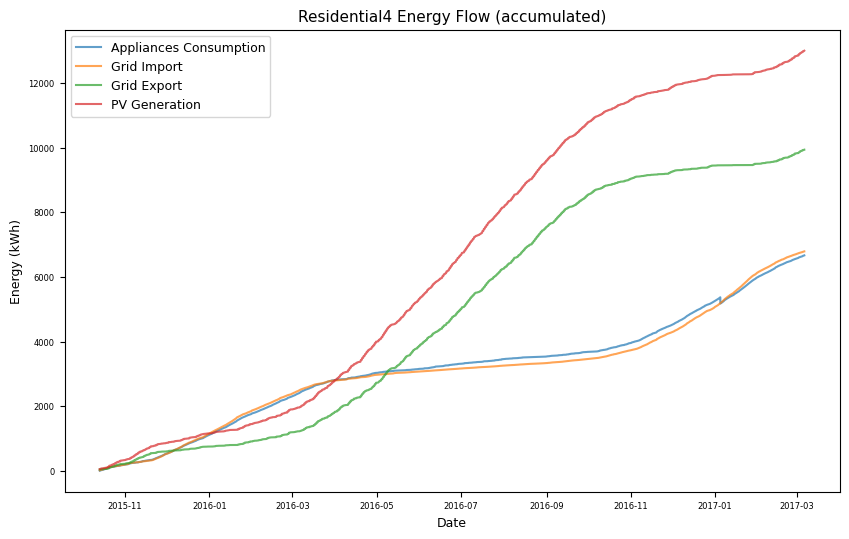

The plot below highlights distinct seasonal trends: during the summer months, both energy demand (`grid_import`) and `appliances` consumption were noticeably lower than during the rest of the year. Conversely, `pv` generation and `grid_export` peaked during this same period. This behavior aligns perfectly with intuitive expectations, as it directly mirrors the shifting weather conditions throughout the year.

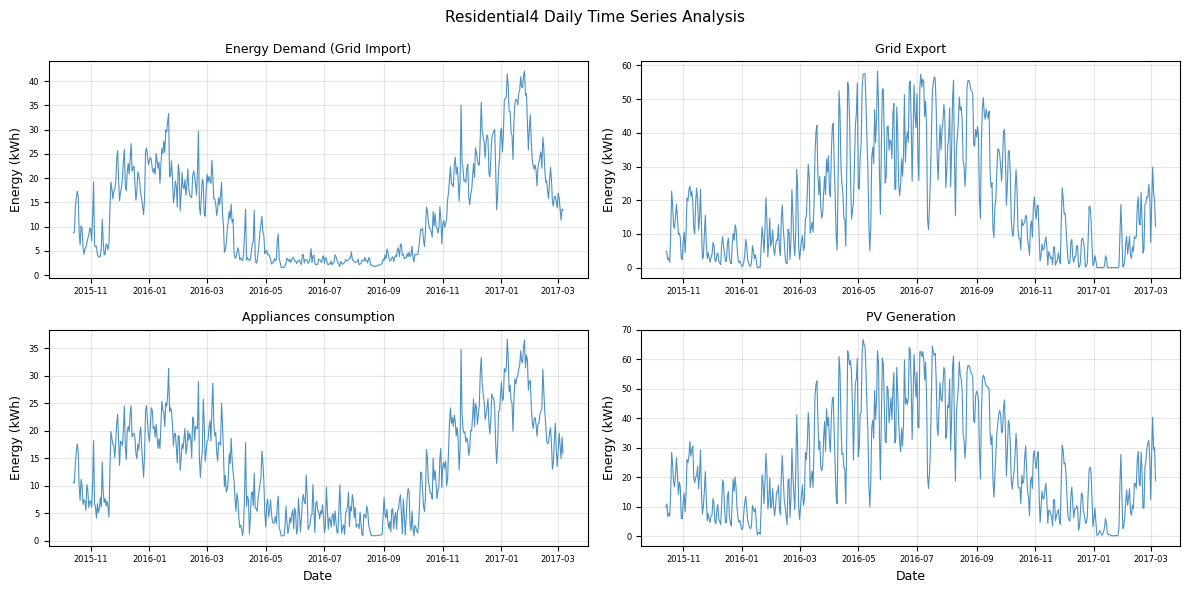

Below, we present histograms of the analyzed appliances and the target variable aggregated at a daily granularity. Most of these distributions are right-skewed, indicating that energy usage and demand were typically concentrated at the lower end of the registered scale.

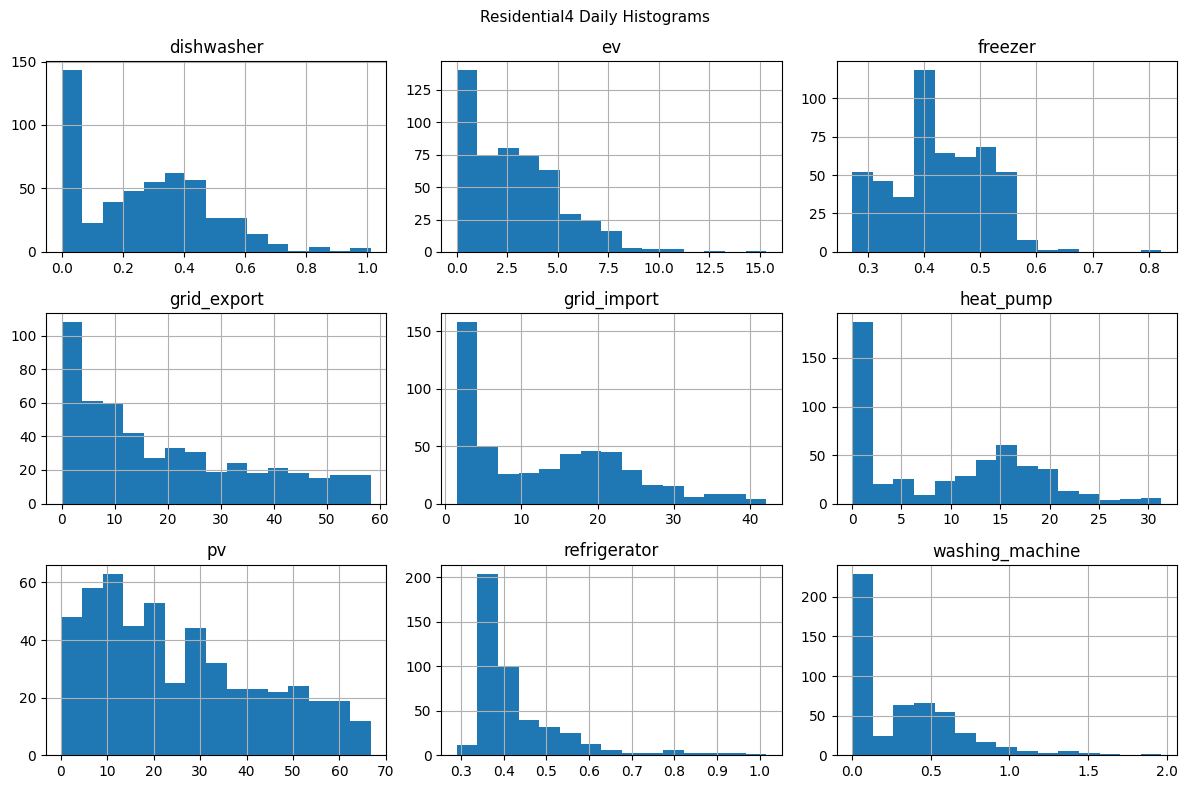

The weather histograms reveal that temperatures remained relatively mild throughout most of the year, generally staying above 0°C and never exceeding 25°C. Meanwhile, both solar radiation distributions are right-skewed, indicating that high-intensity solar exposure was infrequent.

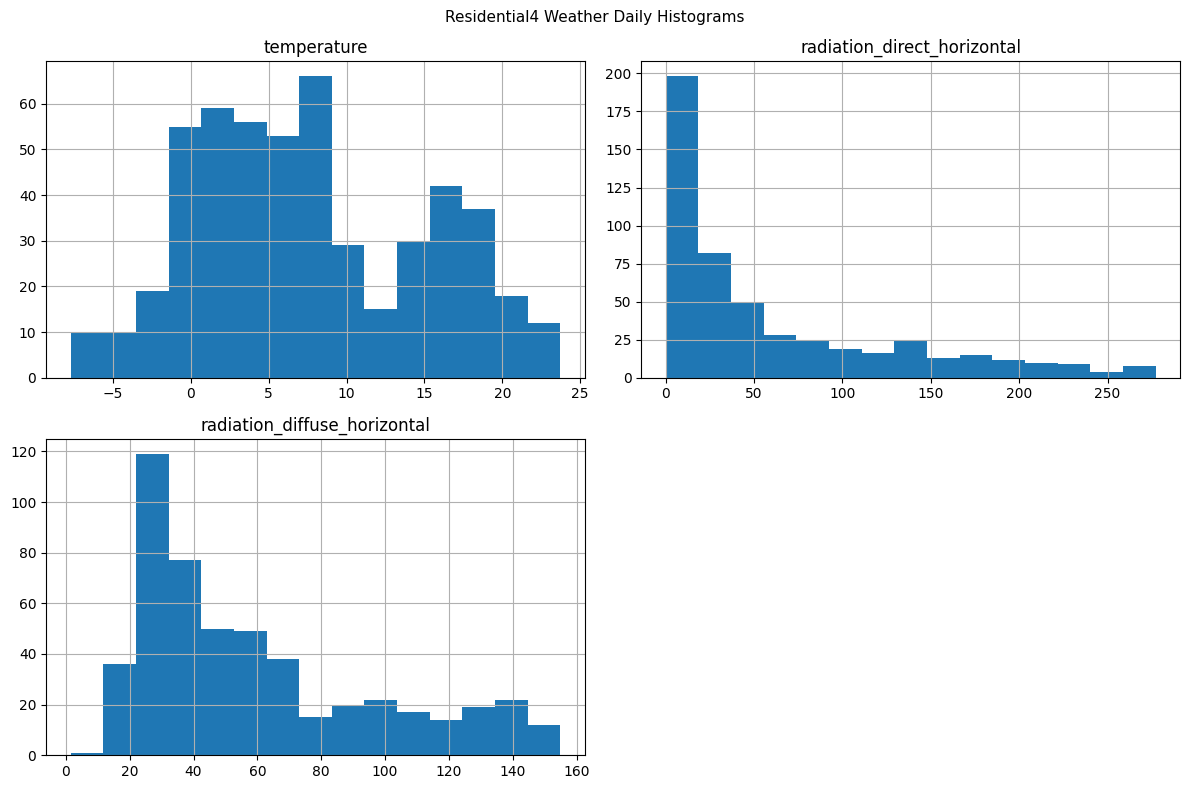

The correlation heatmap below provides valuable insights into how our target variable, `grid_import`, interacts with the other features. Notably, `grid_import` exhibits a very strong positive correlation with `heat_pump` consumption (0.97), indicating that heating demands are a primary driver of grid energy imports. Conversely, it shows strong negative correlations with `freezer` (-0.82), `temperature` (-0.84), `pv` generation (-0.79), and `grid_export` (-0.78). This confirms that during warmer, sunnier periods—when solar generation peaks—the reliance on imported grid energy drops significantly.

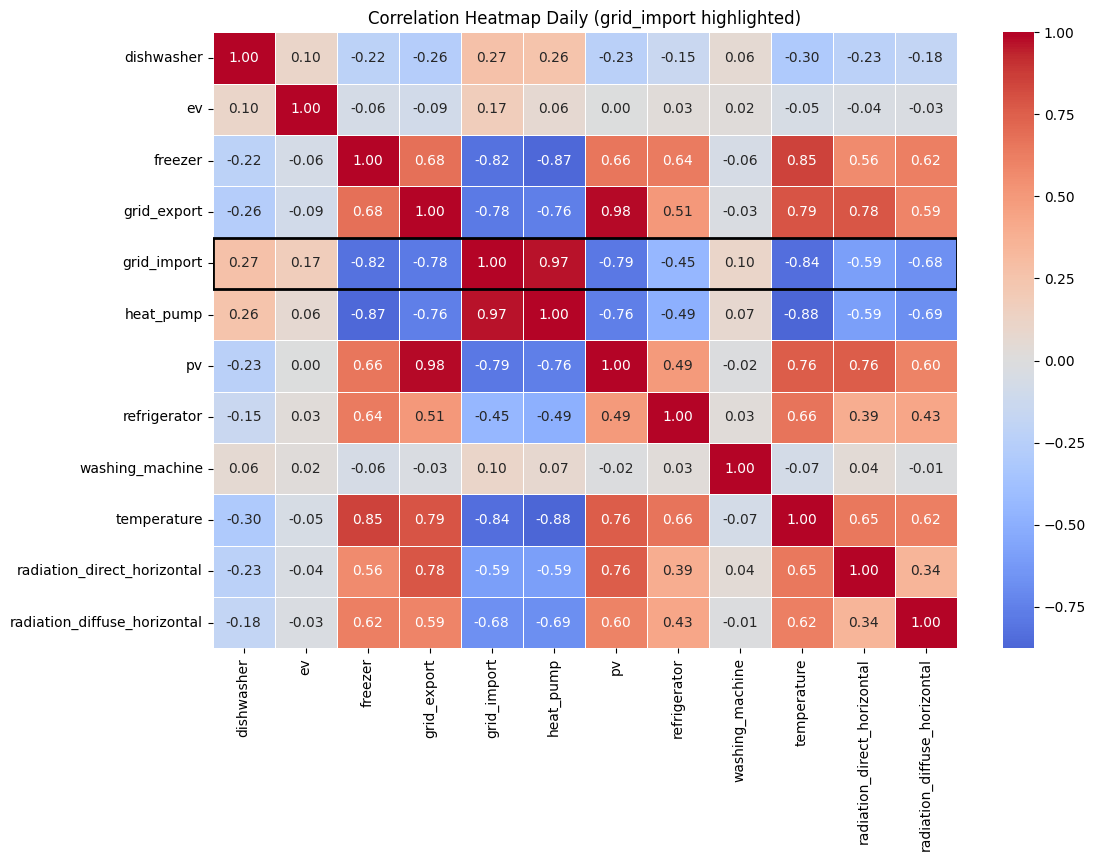

The initial preprocessing steps—including loading the raw data, selecting the filtered time frame, unifying column names, and merging the datasets—are handled automatically by the helper function `clean_raw_data` from the `src.LSTM.preprocess` module. This function processes the raw data files and returns both the hourly and daily merged DataFrames for the Residential4 building.

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
# Go up one level and change directory instantly
os.chdir(Path.cwd().parent)

# Verify the change worked
print("New working directory:", os.getcwd())

New working directory: /Users/joannakusy/pwr/masters/ML_for_Data_Analytics_Project


In [3]:
from src.LSTM.preprocess import clean_raw_data

help(clean_raw_data)

Help on function clean_raw_data in module src.LSTM.preprocess:

clean_raw_data(data_dir)
    Reads raw OPSD data, performs filtering, handles NaNs, and merges
    specific household data with selected weather data columns.

    Args:
        data_dir (str): Path to the 'data/raw' directory.

    Returns:
        tuple: (residential4_hourly_merged, residential4_daily_merged)



In [4]:
df_hourly, df_daily = clean_raw_data(os.path.join(os.getcwd(), "data/raw"))

pd.DataFrame(df_daily).head()

,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
utc_timestamp,,,,,,,,,,,
2015-10-14 00:00:00+00:00,0.009458,3.801208,0.344667,4.847500,8.733000,6.491625,9.906250,0.004542,3.088417,5.377025,55.964250
2015-10-15 00:00:00+00:00,0.473000,3.952000,0.509542,4.565792,8.840375,5.277917,10.963958,0.006667,3.882417,1.886054,43.256808
2015-10-16 00:00:00+00:00,0.468375,2.327250,0.498083,2.365208,13.924917,10.344583,6.637250,0.004750,4.813750,1.658937,41.459929
2015-10-17 00:00:00+00:00,0.009917,4.115250,0.495875,2.849958,16.025792,11.119208,7.825333,0.004750,5.372500,16.392312,62.422004
2015-10-18 00:00:00+00:00,0.581167,5.184708,0.492042,1.611875,17.262167,10.978875,6.890042,0.007833,5.974083,16.178633,60.851612


---

## 4. Feature Engineering

The feature engineering process—which includes generating time-based, seasonal, and holiday features derived during the EDA phase—is handled by the `engineer_features` function from the `src.LSTM.preprocess` module. This function applies the transformations to both the hourly and daily datasets, automatically splitting them into their respective train and test sets. 

The engineered feature set is structured into the following key categories:

* **Target Variable:** Energy Demand (Grid Import) in kWh.
* **Appliance-Level Regressors:** Heat Pump, Washing Machine, Dishwasher, EV, Photovoltaic (PV).
* **Weather & Solar Regressors:** Temperature, Radiation (Direct & Diffuse Horizontal). We utilize the `astral` library to calculate exact dawn/dusk times for solar impact analysis.
* **Temporal Regressors:** Incorporates the `holidays` library for regional holiday flags, alongside weekends, seasons, and cyclical time-of-day encodings.

For a comprehensive walkthrough and visual validation of how these features were developed, please refer to the dedicated notebook at `notebooks/02_feature_engineering.ipynb`.

In [5]:
from src.LSTM.preprocess import engineer_features

help(engineer_features)

Help on function engineer_features in module src.LSTM.preprocess:

engineer_features(df_hourly, df_daily)
    Applies feature engineering from the EDA phase to the hourly and daily datasets.
    Generates time-based, seasonal, and holiday features.

    Args:
        df_hourly (pd.DataFrame): Cleaned hourly data.
        df_daily (pd.DataFrame): Cleaned daily data.

    Returns:
        tuple: (hourly_all, hourly_train, hourly_test, daily_all, daily_train, daily_test)



In [6]:
_, _, _, daily_all, daily_train, daily_test = engineer_features(df_hourly, df_daily)

pd.DataFrame(daily_all).head()

,energy_demand,dishwasher,ev,freezer,grid_export,heat_pump,pv,washing_machine,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,is_holiday_or_weekend,season
utc_timestamp,,,,,,,,,,,,,
2015-10-14 00:00:00+00:00,8.733000,0.009458,3.801208,0.344667,4.847500,6.491625,9.906250,0.004542,3.088417,5.377025,55.964250,False,autumn
2015-10-15 00:00:00+00:00,8.840375,0.473000,3.952000,0.509542,4.565792,5.277917,10.963958,0.006667,3.882417,1.886054,43.256808,False,autumn
2015-10-16 00:00:00+00:00,13.924917,0.468375,2.327250,0.498083,2.365208,10.344583,6.637250,0.004750,4.813750,1.658937,41.459929,False,autumn
2015-10-17 00:00:00+00:00,16.025792,0.009917,4.115250,0.495875,2.849958,11.119208,7.825333,0.004750,5.372500,16.392312,62.422004,True,autumn
2015-10-18 00:00:00+00:00,17.262167,0.581167,5.184708,0.492042,1.611875,10.978875,6.890042,0.007833,5.974083,16.178633,60.851612,True,autumn


The execution of the entire data pipeline—covering preprocessing, feature engineering, and exporting the final datasets—is managed by the `run_data_pipeline` function. This function serves as the central orchestrator, sequentially calling the underlying data preparation modules to generate the final ready-to-model data.

In [7]:
from src.LSTM.preprocess import run_data_pipeline

help(run_data_pipeline)

Help on function run_data_pipeline in module src.LSTM.preprocess:

run_data_pipeline(raw_data_dir, output_data_dir)
    Executes the full data pipeline: Preprocessing -> Feature Engineering -> Saving Data.



---
## 5. Modeling

We conducted a comparison between classical time-series baselines and complex deep learning frameworks. All experiments were tracked using **Weights & Biases (W&B)**.

**1. Classical Baselines (`src/ARIMA/`, `src/ETS/`, `src/Prophet/`):**
* Exponential Smoothing (ETS)
* Prophet (with seasonal regressors)
* SARIMA & SARIMAX (incorporating exogenous weather variables)

**2. Deep Learning Architectures (`src/LSTM/`, `src/TFT/`):**
* LSTM + Dense Layer
* Attention-LSTM
* Encoder/Decoder LSTM (Hyperparameter tuned using Optuna)
* Temporal Fusion Transformer (TFT)

A brief walk-through of each model is presented below. For more details, please refer to `notebooks/04_interpretability.ipynb`.

The Encoder-Decoder LSTM achieves the highest predictive accuracy with a minimum MAE of 2.61 and a MAPE of 10.28%, closely followed by the Temporal Fusion Transformer (TFT) and the seasonal statistical models. In stark contrast, the baseline ETS model performs the worst, exhibiting an exceptionally high MAPE of 43.44% that differs from the top-performing neural network by over 33 percentage points.

### 5.1 ETS with deseasoning

ETS (Error-Trend-Seasonality) models decompose a time series into level, trend and seasonal components. We remove the seasonal cycle first and fit a simple ETS to capture level/trend dynamics as a transparent baseline.

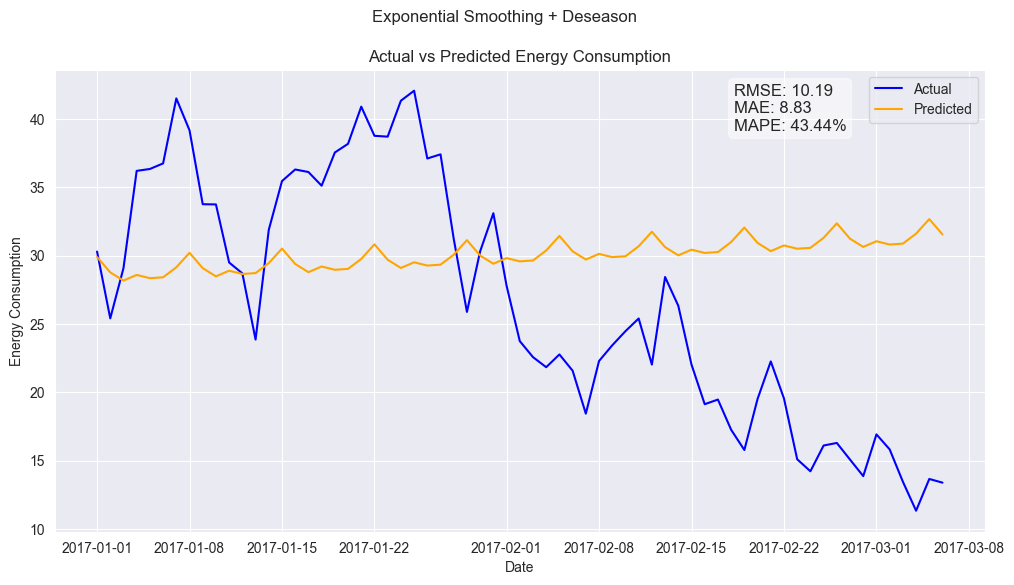

### 5.2 Prophet
Prophet is an additive forecasting model that explicitly models trend, multiple seasonalities and user-provided regressors (holidays or exogenous signals). It is robust to missing data and works well for business time series with changepoints.

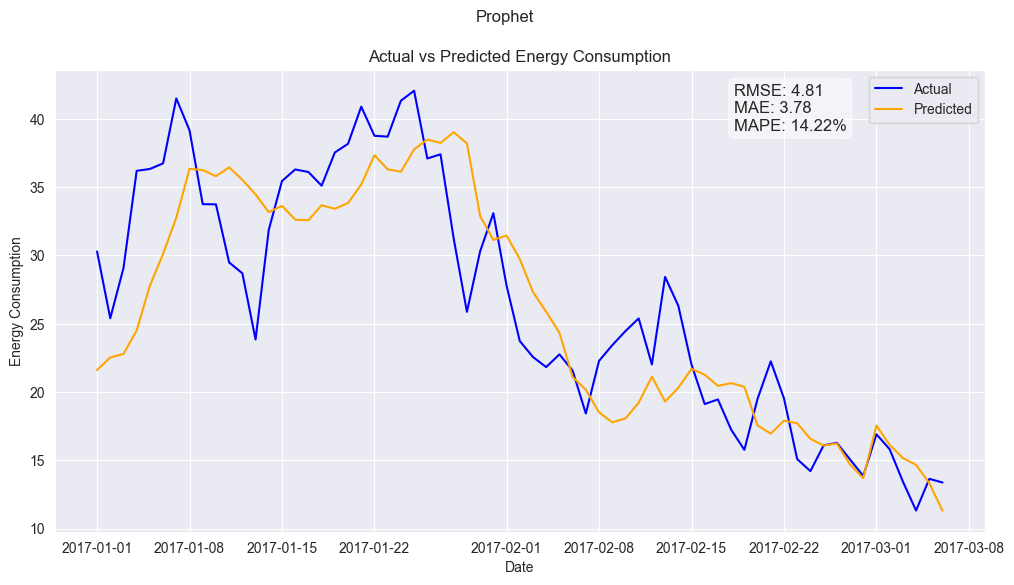

### 5.3 Deseasoned ARIMA(1,1,2)

ARIMA models combine autoregression (AR), differencing (I) to achieve stationarity, and moving average (MA). Here we fit ARIMA on the deseasonalized series so the model focuses on short-term autocorrelation and shocks. The model assumes linear relationships, therefore higher values of certain coefficients indicate stronger influence of past values or errors on the current prediction.

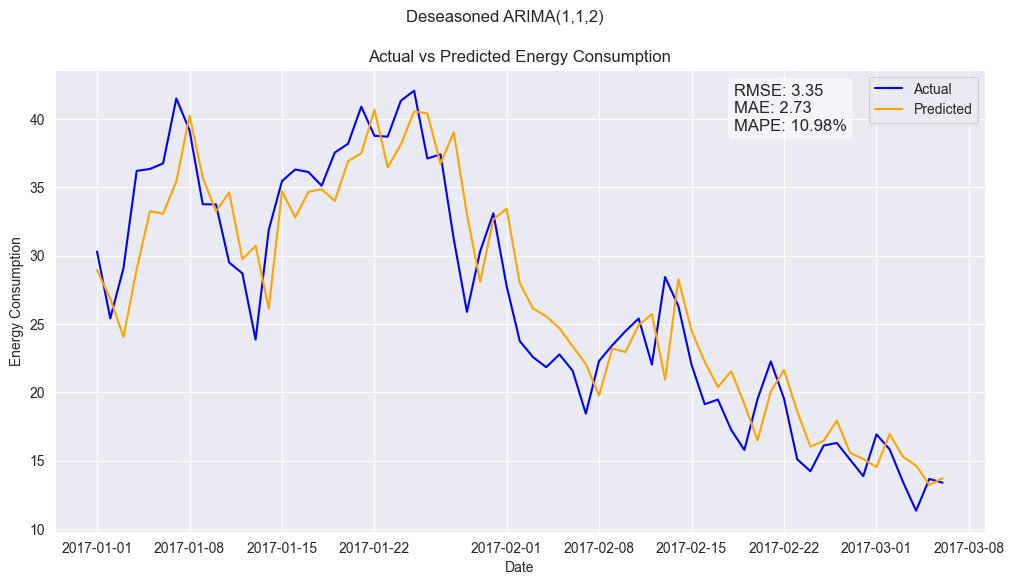

### 5.4 SARIMA(0,1,3)x(1,1,1,7)
SARIMA extends ARIMA with seasonal AR and MA terms to capture repeating patterns at a fixed period.

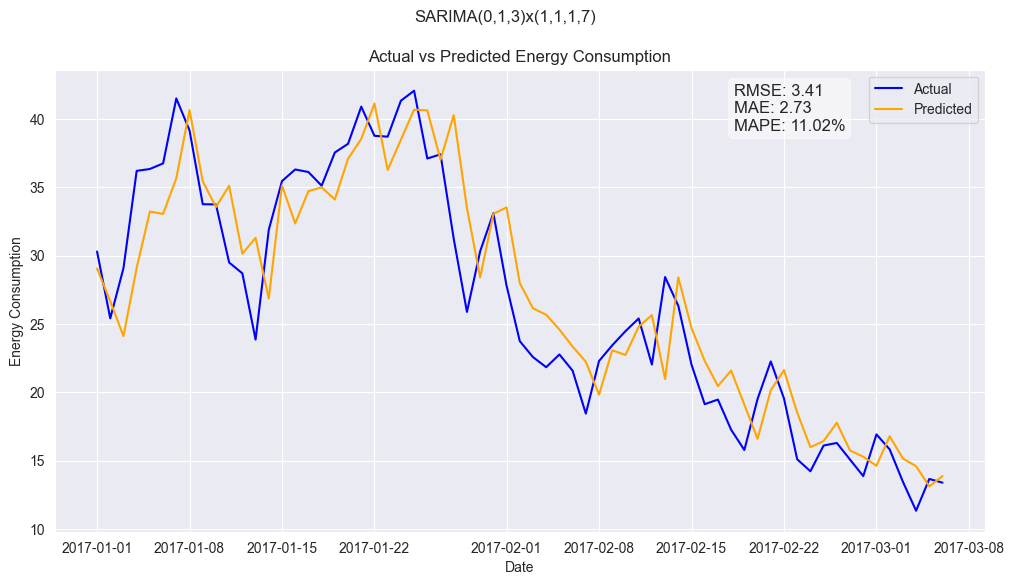

### 5.5 SARIMAX(0,1,3)x(0,1,1,7)
SARIMAX additionally supports exogenous regressors. These are standard statistical approaches for seasonal time series and provide interpretable coefficients and prediction intervals.

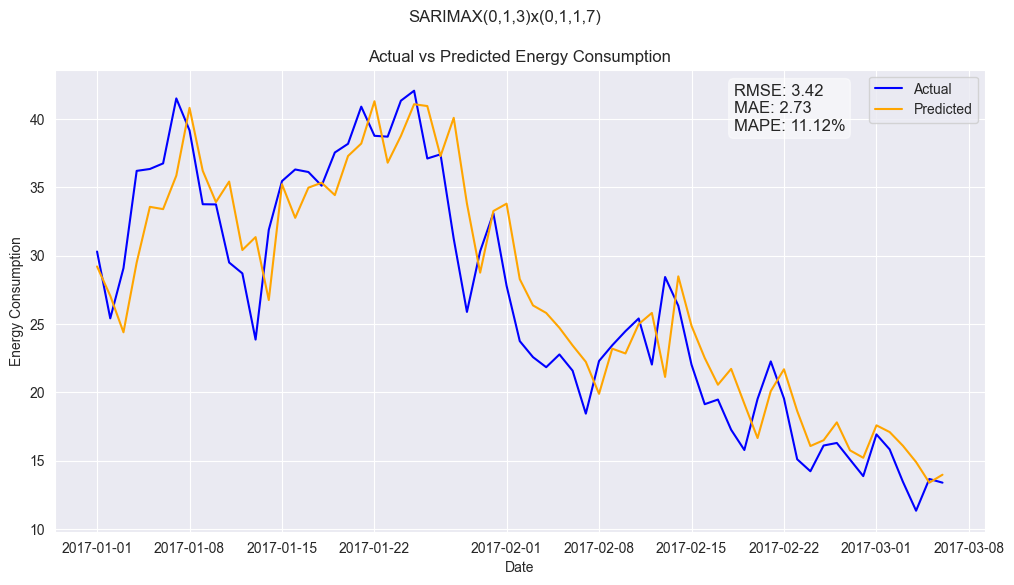

### 5.6 Attention LSTM

The Attention LSTM is a neural sequence model that augments regular LSTM units with an attention mechanism to weight past time steps. It captures nonlinear interactions and temporal importance.

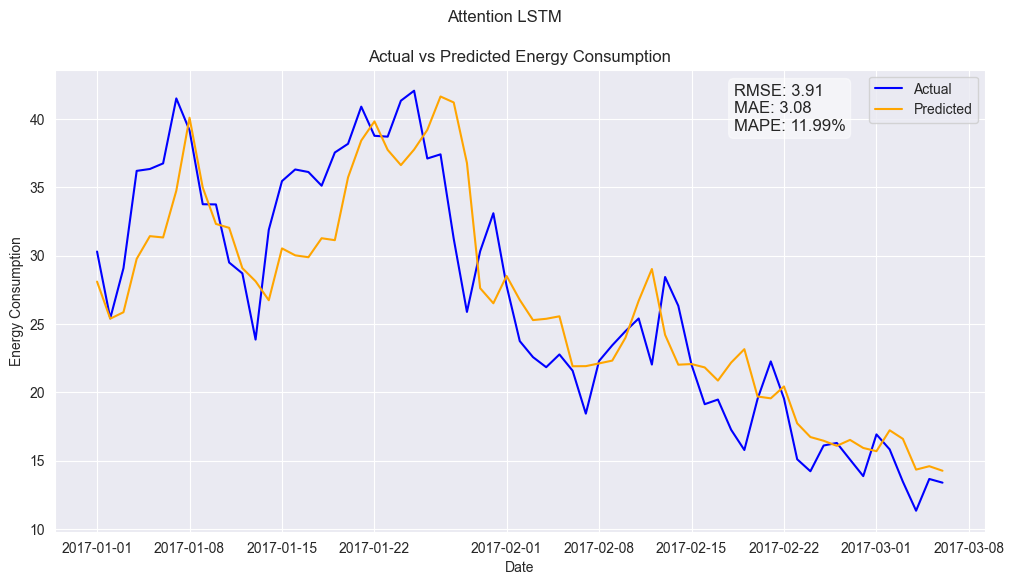

### 5.7 Encoder-decoder LSTM
Encoder-decoder LSTM is a sequence-to-sequence model that uses an encoder to process the input sequence and a decoder to generate the forecast give additional information on the current time step features without leaking those which would not have been available at prediction time. This architecture allows for more flexible modeling of temporal dependencies and can capture complex patterns in the data.

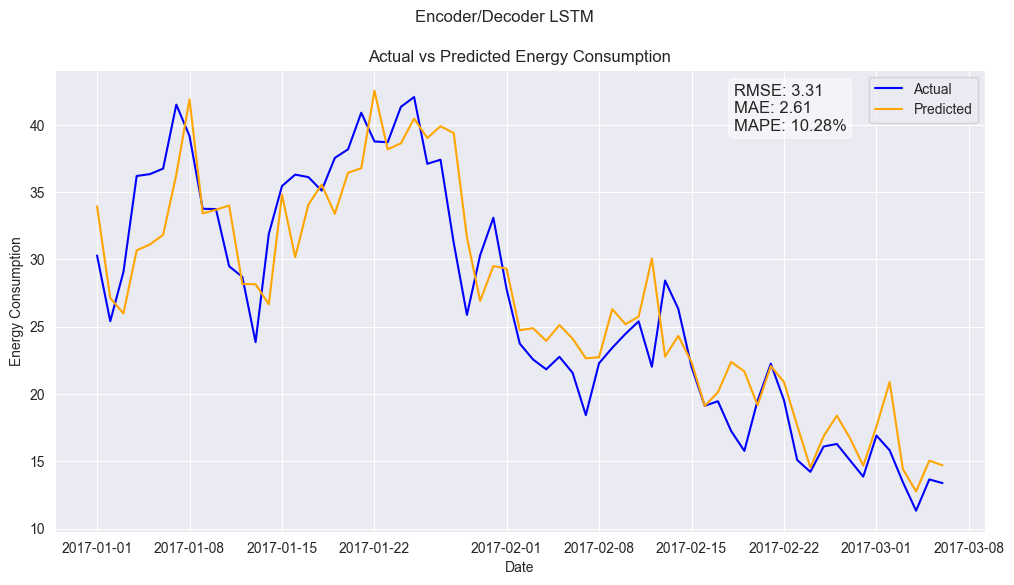

#### 5.8 Temporal Fusion Transformer

The Temporal Fusion Transformer (TFT) is a state-of-the-art architecture that combines recurrent layers with attention mechanisms to capture both short-term and long-term dependencies in time series data. It encompasses previouusly discussed LSTM architectures into one and builds on top of them with a more flexible and powerful attention mechanism that can capture complex temporal patterns and interactions between features. It can handle static covariates, known future inputs, and past observed values, making it highly flexible for forecasting tasks. The TFT also provides interpretability through feature importance and attention weights, allowing us to understand which features and time steps are driving the predictions. 

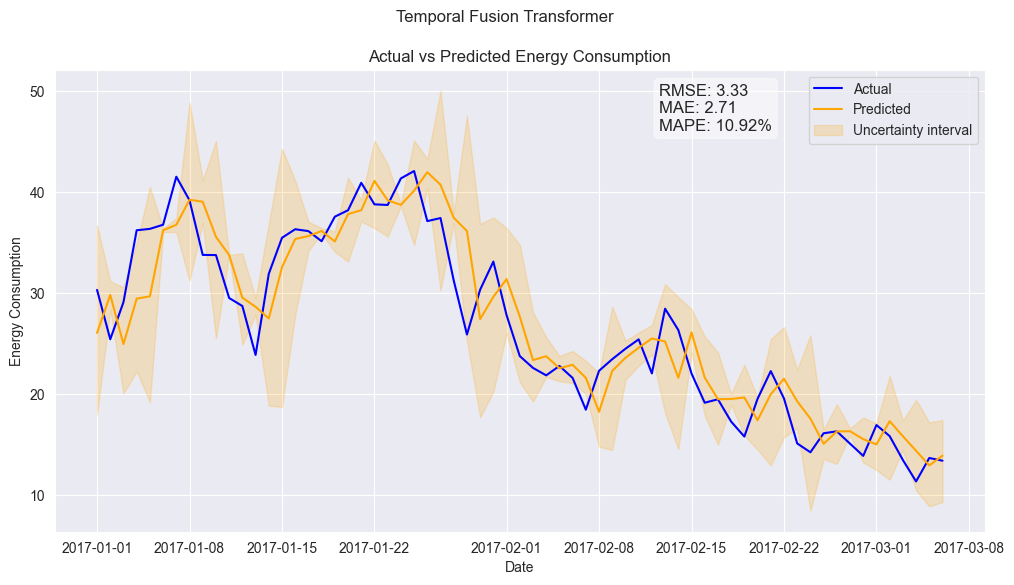

---

## 6.Evaluation

### Evaluation Metrics

* **MAE (Mean Absolute Error)** Measures the average magnitude of absolute errors. It treats all errors linearly.
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

* **RMSE (Root Mean Squared Error)** Measures the square root of average squared differences. It places a heavier penalty on larger errors.
  $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

* **MAPE (Mean Absolute Percentage Error)** Measures the average relative percentage deviation from the actual values.
  $$\text{MAPE (\%)} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

*Where $y_i$ is the actual value, $\hat{y}_i$ is the predicted value, and $n$ is the total number of observations.*

In [ ]:
from IPython.display import IFrame

report_url = "https://api.wandb.ai/links/ml-for-data-analytics-project/512xnfh6"

IFrame(src=report_url, width="100%", height="500px")

In [ ]:
from src.wandb_utils import compile_benchmark_table

# Project Definitions
ENTITY = "ml-for-data-analytics-project"
PROJECT = "energy-forecasting"

filtered_run_ids = [
    "s6hiczdx",
    "1et4nbos",
    "i6nfjq31",
    "znxzbbdy",
    "fwg0uzd9",
    "n3viomoq",
    "c99km3cg",
    "g0rvmyzs",
]

# Run the single wrapper routine
final_metrics_df = compile_benchmark_table(
    entity=ENTITY, project=PROJECT, run_ids=filtered_run_ids
)

# Output your completed comparison table
final_metrics_df

Successfully processed: encdec_lstm_base
Successfully processed: TFT
Successfully processed: DECOMPOSE_ARIMA_order(1, 1, 2)_p7
Successfully processed: SARIMA_order(0, 1, 3)_sorder(1, 1, 1, 7)
Successfully processed: SARIMAX_order(0, 1, 3)_sorder(0, 1, 1, 7)
Successfully processed: LSTMAttentionModel_lr0.001
Successfully processed: Prophet_c_scale5.0_s_scale10.0
Successfully processed: ETS_{'HWS': True, 'seasonal_periods': 7}


,Run Name,Run ID,State,MAE,RMSE,MAPE (%)
0,encdec_lstm_base,s6hiczdx,finished,2.605930,3.308621,10.283071
1,TFT,1et4nbos,finished,2.707597,3.326174,10.922690
2,"SARIMAX_order(0, 1, 3)_sorder(0, 1, 1, 7)",fwg0uzd9,finished,2.725984,3.420405,11.115014
3,"DECOMPOSE_ARIMA_order(1, 1, 2)_p7",i6nfjq31,finished,2.727446,3.352765,10.976243
4,"SARIMA_order(0, 1, 3)_sorder(1, 1, 1, 7)",znxzbbdy,finished,2.728761,3.410608,11.022812
5,LSTMAttentionModel_lr0.001,n3viomoq,finished,3.080398,3.911165,11.987206
6,Prophet_c_scale5.0_s_scale10.0,c99km3cg,finished,3.783602,4.810375,14.217351
7,"ETS_{'HWS': True, 'seasonal_periods': 7}",g0rvmyzs,finished,8.826150,10.187929,43.438786


The Encoder-Decoder LSTM achieves the highest predictive accuracy with a minimum MAE of 2.61 and a MAPE of 10.28%, closely followed by the Temporal Fusion Transformer (TFT) and the seasonal statistical models. In stark contrast, the baseline ETS model performs the worst, exhibiting an exceptionally high MAPE of 43.44% that differs from the top-performing neural network by over 33 percentage points.

---

## 7. Interpretability

To evaluate model reliability, we performed an interpretability analysis. This process is lightweight for classical models and more detailed for the neural and hybrid frameworks, where SHAP, attention, and counterfactual analysis are more informative. Below, we present the interpretability results for one baseline model and one deep learning architecture. For more details, please refer to `notebooks/04_interpretability.ipynb`.

### 7.1 Deseasoned ARIMA(1,1,2)

<table class="simpletable">
<caption>SARIMAX Results</caption>
<tr>
  <th>Dep. Variable:</th>           <td>y</td>        <th>  No. Observations:  </th>    <td>445</td>   
</tr>
<tr>
  <th>Model:</th>            <td>ARIMA(1, 1, 2)</td>  <th>  Log Likelihood     </th> <td>-1075.695</td>
</tr>
<tr>
  <th>Date:</th>            <td>Sun, 07 Jun 2026</td> <th>  AIC                </th> <td>2159.391</td> 
</tr>
<tr>
  <th>Time:</th>                <td>20:38:21</td>     <th>  BIC                </th> <td>2175.774</td> 
</tr>
<tr>
  <th>Sample:</th>             <td>10-14-2015</td>    <th>  HQIC               </th> <td>2165.851</td> 
</tr>
<tr>
  <th></th>                   <td>- 12-31-2016</td>   <th>                     </th>     <td> </td>    
</tr>
<tr>
  <th>Covariance Type:</th>        <td>opg</td>       <th>                     </th>     <td> </td>    
</tr>
</table>
<table class="simpletable">
<tr>
     <td></td>       <th>coef</th>     <th>std err</th>      <th>z</th>      <th>P>|z|</th>  <th>[0.025</th>    <th>0.975]</th>  
</tr>
<tr>
  <th>ar.L1</th>  <td>    0.1987</td> <td>    0.103</td> <td>    1.931</td> <td> 0.053</td> <td>   -0.003</td> <td>    0.400</td>
</tr>
<tr>
  <th>ma.L1</th>  <td>   -0.3364</td> <td>    0.102</td> <td>   -3.288</td> <td> 0.001</td> <td>   -0.537</td> <td>   -0.136</td>
</tr>
<tr>
  <th>ma.L2</th>  <td>   -0.3438</td> <td>    0.054</td> <td>   -6.353</td> <td> 0.000</td> <td>   -0.450</td> <td>   -0.238</td>
</tr>
<tr>
  <th>sigma2</th> <td>    7.4381</td> <td>    0.333</td> <td>   22.351</td> <td> 0.000</td> <td>    6.786</td> <td>    8.090</td>
</tr>
</table>
<table class="simpletable">
<tr>
  <th>Ljung-Box (L1) (Q):</th>     <td>0.00</td> <th>  Jarque-Bera (JB):  </th> <td>227.39</td>
</tr>
<tr>
  <th>Prob(Q):</th>                <td>0.99</td> <th>  Prob(JB):          </th>  <td>0.00</td> 
</tr>
<tr>
  <th>Heteroskedasticity (H):</th> <td>0.64</td> <th>  Skew:              </th>  <td>-0.19</td>
</tr>
<tr>
  <th>Prob(H) (two-sided):</th>    <td>0.01</td> <th>  Kurtosis:          </th>  <td>6.48</td> 
</tr>
</table><br/><br/>Warnings:<br/>[1] Covariance matrix calculated using the outer product of gradients (complex-step).

Estimated coefficients for moving average terms appear statistically significant, whereas autoregressive component's significance is less clear. Tests for heterskedasticity and autocorrelation of residuals suggest the variability was well explained. The Jarque-Bera test indicates residuals are not perfectly normal, likely due to remaining structure or heavy tails, but the model captures the main dynamics of the deseasonalized series.

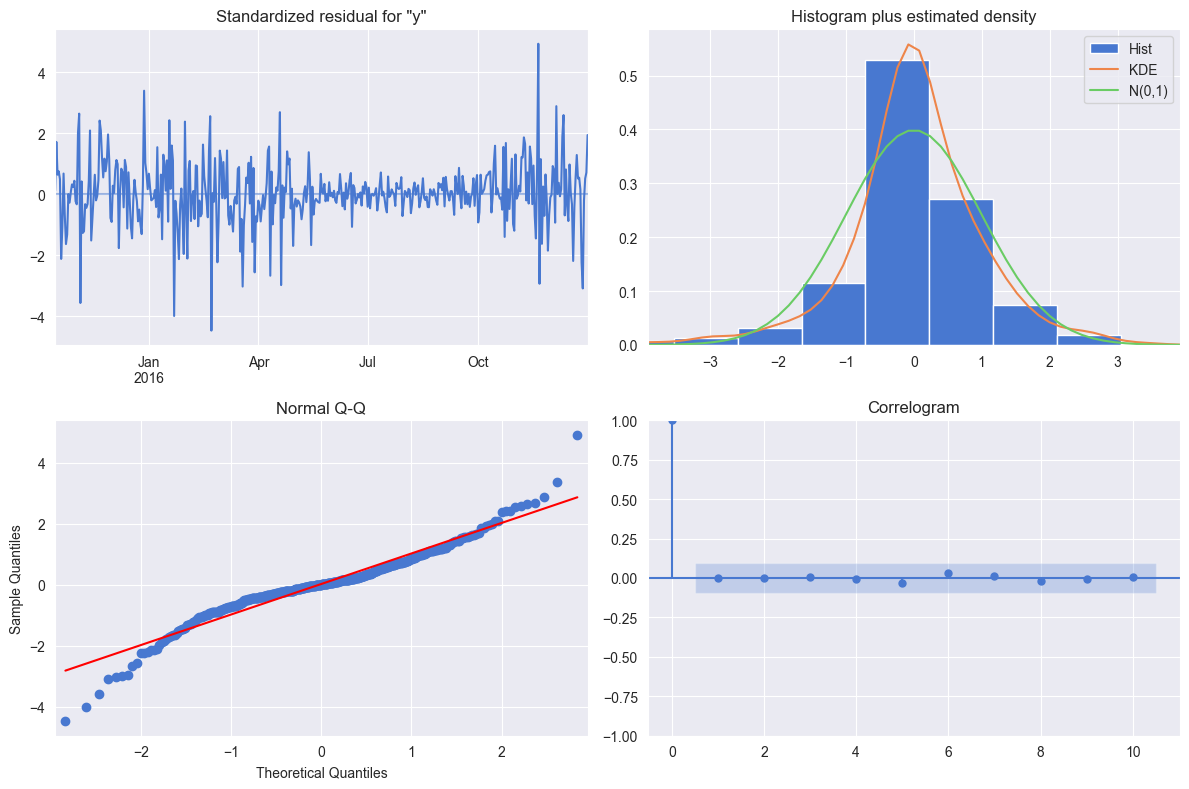

The fit is not very satisfactory as the residuals exhibit fatter tails compared to a normal distribution. This is mainly due to the fact that seasonality was not fully captured by the simple deseasoning process. 

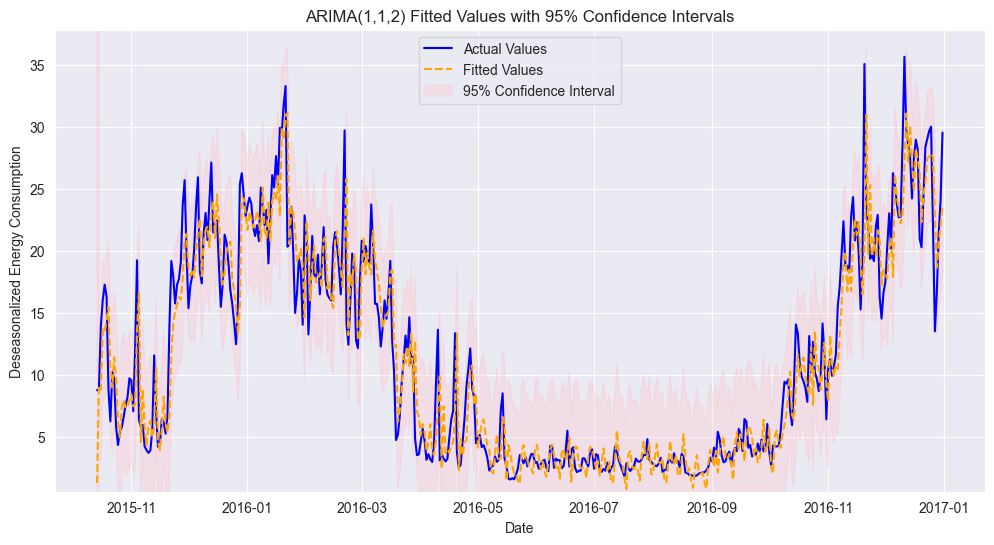

**Interpretation:**
- ARIMA on deseasonalized data is useful to capture inertia and shock-reversion, but not ideal if seasonality or exogenous drivers materially affect peaks.

### 7.2 Attention LSTM

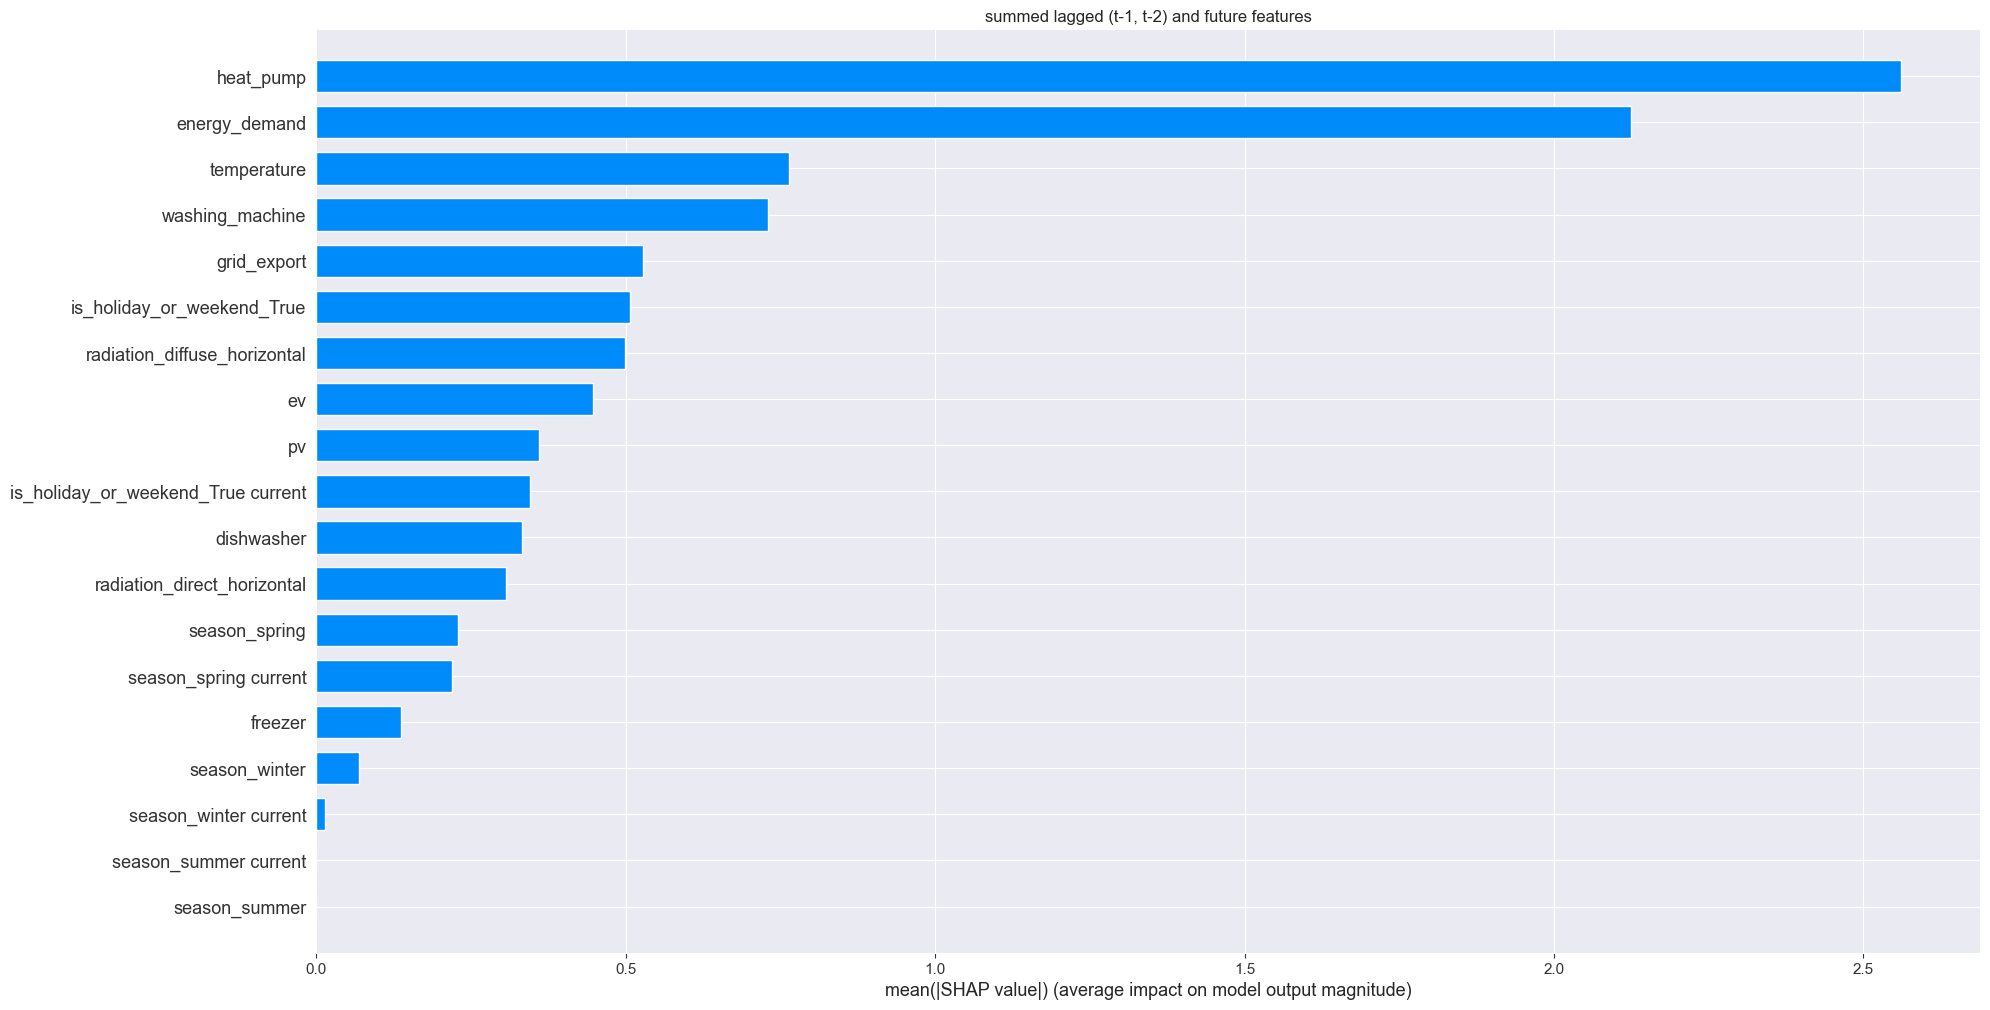

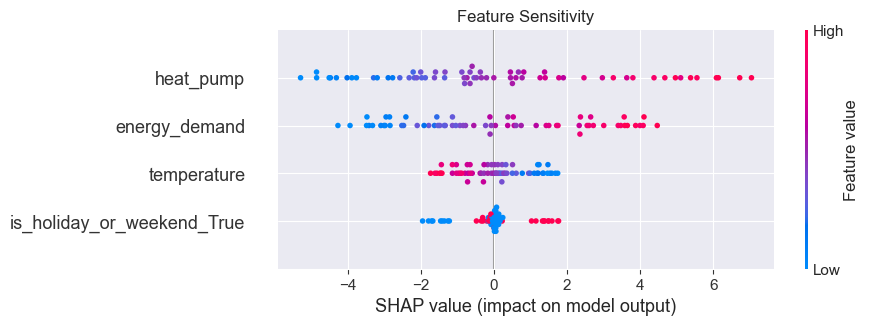

The heat pump feature shows a strong positive SHAP value, indicating that higher heat pump usage is associated with increased energy demand. This makes intuitive sense, as heat pumps consume electricity to operate. The temperature feature has a negative SHAP value, suggesting that higher temperatures lead to lower energy demand, likely due to reduced heating needs. The is_holiday_or_weekend_True feature has a positive SHAP value, indicating that holidays and weekends are associated with increased energy demand, possibly due to more people being at home and using appliances.

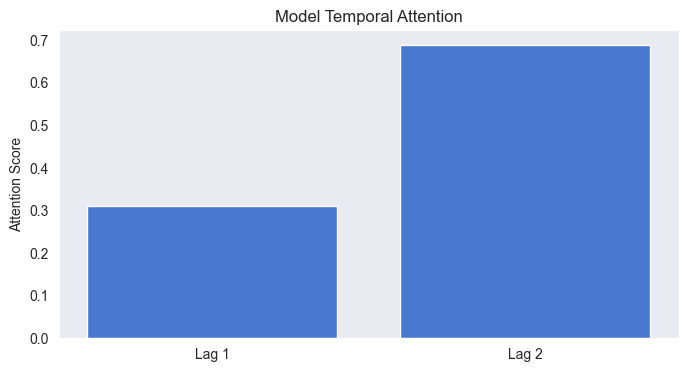

Model's attention weights indicate clearly that the most recent time step is the most important for the prediction. This is consistent with the intuition that recent values are more predictive of the next time step in a time series. The attention mechanism allows the model to focus on the most relevant parts of the input sequence, which can improve forecasting performance compared to a standard LSTM that treats all past time steps equally.

Now, we visualize prediction for the 1st time step and investigate the local impact of main drivers of the prediction using SHAP values.

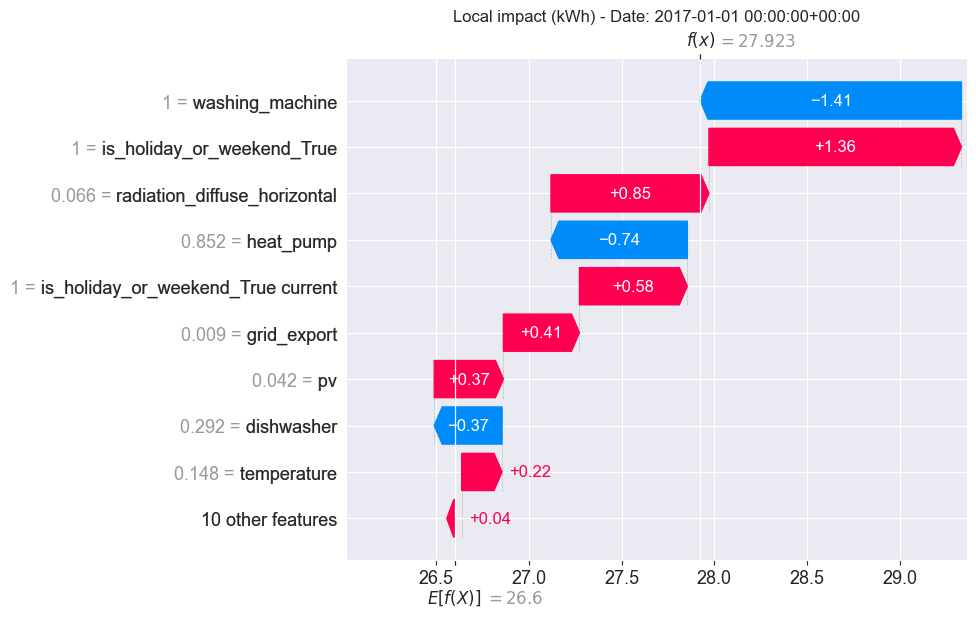

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>0</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>date</th>
      <td>2017-01-01 00:00:00+00:00</td>
    </tr>
    <tr>
      <th>actual_kWh</th>
      <td>30.293125</td>
    </tr>
    <tr>
      <th>predicted_kWh</th>
      <td>28.09294</td>
    </tr>
    <tr>
      <th>error</th>
      <td>2.200185</td>
    </tr>
    <tr>
      <th>norm_energy_demand</th>
      <td>0.820711</td>
    </tr>
    <tr>
      <th>norm_dishwasher</th>
      <td>0.292096</td>
    </tr>
    <tr>
      <th>norm_ev</th>
      <td>0.122902</td>
    </tr>
    <tr>
      <th>norm_freezer</th>
      <td>0.0</td>
    </tr>
    <tr>
      <th>norm_grid_export</th>
      <td>0.009274</td>
    </tr>
    <tr>
      <th>norm_heat_pump</th>
      <td>0.851559</td>
    </tr>
    <tr>
      <th>norm_pv</th>
      <td>0.042116</td>
    </tr>
    <tr>
      <th>norm_washing_machine</th>
      <td>1.0</td>
    </tr>
    <tr>
      <th>norm_temperature</th>
      <td>0.147846</td>
    </tr>
    <tr>
      <th>norm_radiation_direct_horizontal</th>
      <td>0.084384</td>
    </tr>
    <tr>
      <th>norm_radiation_diffuse_horizontal</th>
      <td>0.066249</td>
    </tr>
    <tr>
      <th>norm_is_holiday_or_weekend_True</th>
      <td>1.0</td>
    </tr>
    <tr>
      <th>norm_season_spring</th>
      <td>0.0</td>
    </tr>
    <tr>
      <th>norm_season_summer</th>
      <td>0.0</td>
    </tr>
    <tr>
      <th>norm_season_winter</th>
      <td>1.0</td>
    </tr>
    <tr>
      <th>norm_is_holiday_or_weekend_True current</th>
      <td>1.0</td>
    </tr>
    <tr>
      <th>norm_season_spring current</th>
      <td>0.0</td>
    </tr>
    <tr>
      <th>norm_season_summer current</th>
      <td>0.0</td>
    </tr>
    <tr>
      <th>norm_season_winter current</th>
      <td>1.0</td>
    </tr>
  </tbody>
</table>
</div>

For this specific time step (January 1, 2017—New Year's Day holiday), the model predicts a higher-than-average grid import of 28.73 kWh.
The main reasons for this high import are the fact that it is a holiday/weekend, combined with poor weather/low solar conditions (low radiation, low PV output) which prevents self-generation. This extra demand is only partially mitigated by the current operational states of the washing machine and heat pump.

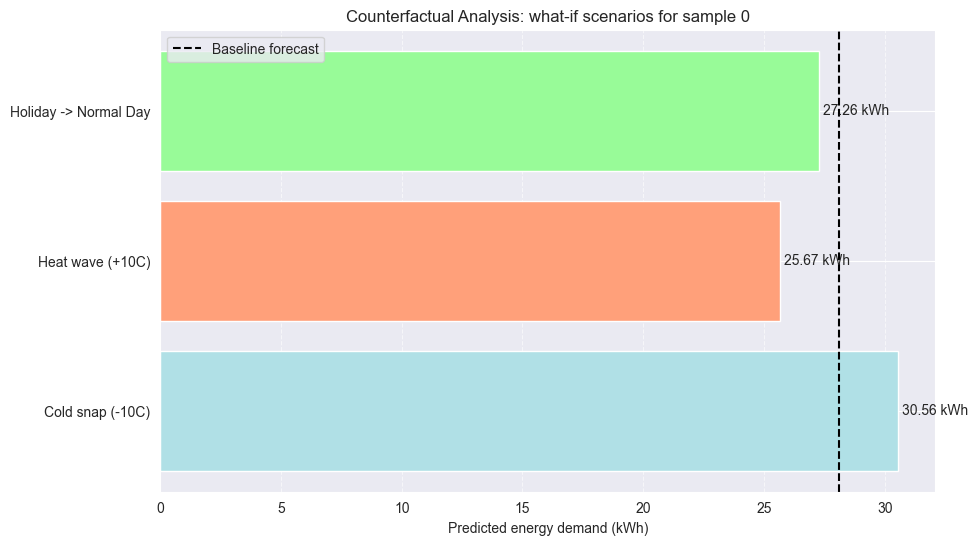

{'Cold snap (-10C)': np.float64(30.564592457077794), <br>
 'Heat wave (+10C)': np.float64(25.672090301277194), <br>
 'Holiday -> Normal Day': np.float64(27.26166556100491)}

Model's behavior is consistent with domain knowledge: holidays and poor weather conditions lead to higher grid imports due to reduced self-generation and increased demand. The SHAP values provide a clear explanation of how each feature contributes to the prediction, which enhances the interpretability of the model and builds trust in its forecasts.

## 8. Conclusions 

**Key findings**

- Forecasting models (statistical and ML/DL) produce reliable daily `grid_import` predictions when trained on the selected data and features.
- Model interpretability (SHAP) consistently identifies `heat_pump`, temperature and PV generation as the main drivers of predictions.

**Limitations**

- Analysis is based on a single residential building (Residential4) and a limited time span (Oct 2015–Mar 2017), which constrains generalisability.
- Several potentially useful time-series features (from the Time series dataset) were not used in the final models, which may limit predictive power.
- Results presented are model-level and interpretability checks; they do not replace operational validation in production settings.

**Future work**

- Expand data across more buildings and longer periods to improve robustness and transferability.
- Incorporate additional time-series features and exogenous inputs (weather forecasts, occupancy proxies) and evaluate probabilistic forecasting methods.
- Evaluate online retraining and monitored deployment (using the existing dashboard) to assess real-world performance and model drift.
